In [31]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
# Load the cleaned dataset
df = pd.read_csv("Final_Cleaned_Panel_Dataset.csv")
# Preview dataset
print(df.head())


            State  Year  Total_Flood_Events  Total_Fatalities  \
0  Andhra Pradesh  2001                 0.0               0.0   
1  Andhra Pradesh  2002                 0.0               0.0   
2  Andhra Pradesh  2003                 0.0               0.0   
3  Andhra Pradesh  2004                 2.0              14.0   
4  Andhra Pradesh  2005                 1.0               9.0   

   Mean_Duration_Days  Annual_Tree_Loss_ha  Annual_Percent_Tree_Loss  \
0                 0.0               1098.4                  0.099321   
1                 0.0               1098.4                  0.099321   
2                 0.0               1098.4                  0.099321   
3                 2.5               1098.4                  0.099321   
4                 1.0               1098.4                  0.099321   

   Indo_Event_Count  Annual_Rainfall  Monsoon_Rainfall  Max_Daily_Rainfall  \
0               2.0       786.755286        491.399726           90.389112   
1               0.0 

In [13]:
df =df.set_index(["State","Year"])

In [14]:
# Rainfall × Tree Loss interaction
df["Rain_Tree_Interaction"] = (
    df["Annual_Rainfall"] * df["Annual_Percent_Tree_Loss"]
)

In [15]:
y = df["Total_Flood_Events"]

In [16]:
# Environmental predictors
X = df[
[
"Annual_Rainfall",
"Max_Daily_Rainfall",
"Annual_Percent_Tree_Loss",
"Rain_Tree_Interaction"
]
]

In [17]:
# Add constant term (intercept)
X = sm.add_constant(X)

In [18]:
model = PanelOLS(
    y,
    X,
    entity_effects=True,   # controls for state-specific characteristics
    time_effects=True      # controls for year-specific climate effects
)

In [19]:
results = model.fit(
    cov_type="clustered",
    cluster_entity=True
)

In [20]:
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     Total_Flood_Events   R-squared:                        0.0122
Estimator:                   PanelOLS   R-squared (Between):             -0.0963
No. Observations:                 640   R-squared (Within):               0.0189
Date:                Wed, Mar 04 2026   R-squared (Overall):             -0.0413
Time:                        03:44:31   Log-likelihood                   -1273.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.8132
Entities:                          32   P-value                           0.1247
Avg Obs:                       20.000   Distribution:                   F(4,585)
Min Obs:                       20.000                                           
Max Obs:                       20.000   F-statistic (robust):             1.9702
                            

In [21]:
df['log_flood_events'] = np.log(df['Total_Flood_Events'] + 1)

df['log_rainfall'] = np.log(df['Annual_Rainfall'] + 1)

df['log_monsoon_rainfall'] = np.log(df['Monsoon_Rainfall'] + 1)

df['log_max_daily_rain'] = np.log(df['Max_Daily_Rainfall'] + 1)

df['log_tree_loss_percent'] = np.log(df['Annual_Percent_Tree_Loss'] + 1)

In [22]:
df['log_lag_tree_loss_percent'] = np.log(df['Lagged_Annual_Percent_Tree_Loss'] + 1)

df['log_lag_rainfall'] = np.log(df['Lagged_Annual_Rainfall'] + 1)

In [23]:
Y = df['log_flood_events']

In [24]:
X = df[[
    'log_rainfall',
    'log_monsoon_rainfall',
    'log_max_daily_rain',
    'log_tree_loss_percent',
    'log_lag_tree_loss_percent'
]]

In [25]:
X = sm.add_constant(X)

In [26]:
model = PanelOLS(
    Y,
    X,
    entity_effects=True,
    time_effects=True
)

results = model.fit(cov_type='clustered', cluster_entity=True)

print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:       log_flood_events   R-squared:                        0.0512
Estimator:                   PanelOLS   R-squared (Between):             -0.4498
No. Observations:                 608   R-squared (Within):               0.0614
Date:                Wed, Mar 04 2026   R-squared (Overall):             -0.2224
Time:                        03:44:31   Log-likelihood                   -391.75
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.9628
Entities:                          32   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(5,553)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             6.4245
                            

C:\Users\singh\AppData\Local\Programs\Python\Python310\lib\site-packages\linearmodels\panel\model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


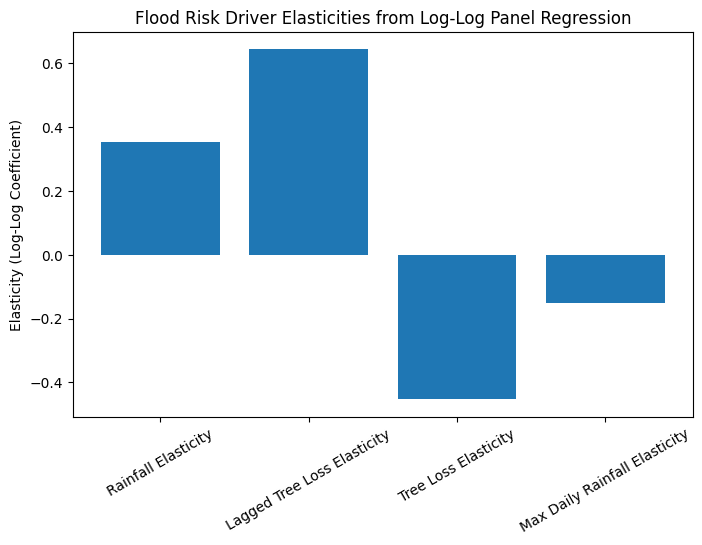

In [27]:
import matplotlib.pyplot as plt

# Elasticity coefficients from the log-log panel regression results
drivers = [
    "Rainfall Elasticity",
    "Lagged Tree Loss Elasticity",
    "Tree Loss Elasticity",
    "Max Daily Rainfall Elasticity"
]

elasticity_values = [
    0.3534,   # log_rainfall coefficient
    0.6422,   # log_lag_tree_loss_percent coefficient
    -0.4533,  # log_tree_loss_percent coefficient
    -0.1511   # log_max_daily_rain coefficient
]

# Create bar plot
plt.figure(figsize=(8,5))
plt.bar(drivers, elasticity_values)

# Labels and title
plt.ylabel("Elasticity (Log-Log Coefficient)")
plt.title("Flood Risk Driver Elasticities from Log-Log Panel Regression")

# Rotate labels for readability
plt.xticks(rotation=30)

# Show plot
plt.show()